# Leakage-safe predictive process monitoring

Predict an adverse outcome after three completed activities. The split is temporal, preprocessing is fitted on training cases only, and the model is compared with a base-rate baseline.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
while not (root / 'labs').exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))
from labs.common import load_module, load_variant_lab
lab = load_module('predictive_monitoring_lab', root / 'labs/05-predictive-monitoring/predictive_monitoring_lab.py')
events = load_variant_lab().generate_event_log()
prefixes = lab.build_prefix_table(events)
model, metrics, predictions = lab.evaluate_models(prefixes)
display(prefixes.head())
display(metrics)

,case_id,start_time,current_activity,channel,product_type,priority,amount,elapsed_hours,activities_seen,check_count,clarify_count,target
0,C-0001,2025-01-06 15:03:20.383862896,Approve,web,standard,normal,348.431570,4.298587,3,1,0,1
1,C-0002,2025-01-07 02:37:44.874626150,Approve,web,standard,normal,299.429903,2.977016,3,1,0,0
2,C-0003,2025-01-08 00:20:52.477788554,Clarify,web,custom,normal,91.558552,7.353578,3,1,1,1
3,C-0004,2025-01-08 14:29:13.288208040,Approve,web,standard,high,470.682300,4.965965,3,1,0,0
4,C-0005,2025-01-09 12:27:55.206169333,Clarify,web,standard,normal,678.757690,6.705047,3,1,1,0


,model,roc_auc,brier,balanced_accuracy
0,prefix logistic regression,0.674074,0.229295,0.552778
1,base-rate baseline,0.500000,0.254776,0.500000


,case_id,start_time,target,risk
189,C-0206,2025-06-09 05:16:56.207935697,1,0.880736
205,C-0224,2025-06-22 19:38:36.826824072,1,0.875081
159,C-0173,2025-05-15 10:30:51.573009096,1,0.864472
178,C-0194,2025-05-31 02:43:19.158776364,1,0.853901
217,C-0236,2025-07-01 15:47:58.593646145,1,0.851241
160,C-0174,2025-05-16 07:53:19.811553601,1,0.845092
165,C-0179,2025-05-20 00:33:07.643607615,0,0.821074
182,C-0198,2025-06-03 08:50:56.154840351,0,0.816315
188,C-0205,2025-06-08 11:34:49.806059589,1,0.812585
161,C-0175,2025-05-16 23:43:26.894775639,0,0.791028


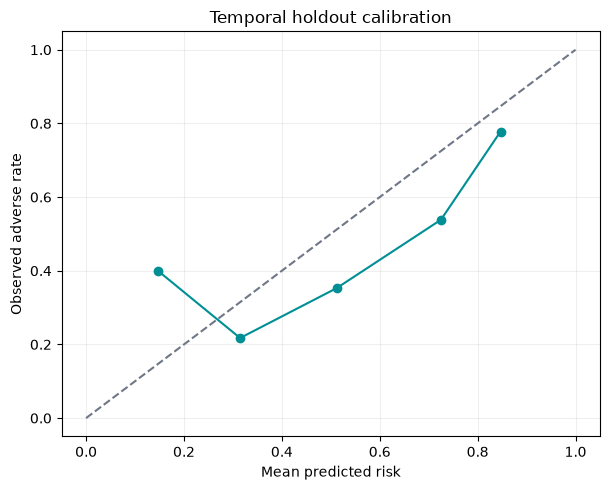

In [2]:
lab.plot_calibration(predictions)
display(predictions.sort_values('risk', ascending=False).head(10))

## Deployment review

Identify the intervention enabled by this prediction point. Discuss false-alarm capacity, calibration, subgroup errors, drift monitoring, and why outcome or post-completion documents would be leakage.